## ⚠️ 先跑这个: 确认内核加载的是最新模块

Python 会把 import 过的模块缓存在 `sys.modules` 里. **你改了 `data_merger.py`,
但内核不会自动重读** —— 这会让你对着新文件调试旧代码.

下面这个 cell 会强制重新加载并打印版本号. 如果版本不是 `3.1`,
请 **Kernel → Restart Kernel**, 然后从头再跑一遍.

In [1]:
import sys, importlib
from pathlib import Path

SRC = Path.cwd().parent / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# 强制重新加载, 绕过 sys.modules 缓存
for m in ('data_merger', 'data_loader'):
    if m in sys.modules:
        importlib.reload(sys.modules[m])

import data_merger
print('data_merger 文件位置:', data_merger.__file__)
print('data_merger 版本:', getattr(data_merger, '__version__', '(无版本号 = 旧版!)'))

assert getattr(data_merger, '__version__', None) == '3.1', (
    '\n\n加载的不是 v3.1!\n'
    '  1. 确认新文件已覆盖到上面打印的路径\n'
    '  2. Kernel -> Restart Kernel\n'
    '  3. 从第一个 cell 重新跑\n')
print('\n✓ 内核加载的是 v3.1, 可以继续')

data_merger 文件位置: D:\User1\UoB_Coursework\FinalProject\src\data_merger.py
data_merger 版本: 3.1

✓ 内核加载的是 v3.1, 可以继续


# 03 — Multi-Source Data Merge (DepMap + HPA + GEO)

在 `01_Data_Upload` (仅 DepMap) 之上补全 HPA + GEO, 输出统一长表 + 单基因宽表.

**依赖**: `src/data_loader.py` (原有) + `src/data_merger.py` (v3.1)

---
## 本 notebook 建立的 ID 对齐链路 (全部为精确查表)

```
枢纽:  CVCL_xxxx  <──>  ACH-xxxxxx
         ↑ 由两条来源共同建立:
         A) sample_info 的 RRID 列          (1,840 条, 最权威)
         B) Cellosaurus 的 Cross-references (DepMap; ACH-xxxxxx)

DepMap RNA   : 行已经是 ACH                        → 直接用
HPA  (File 1): Cell line ──File 11 的 Cellosaurus ID──▶ CVCL ──▶ ACH
GEO  (File 3): GSM ──File 10 的 Cellosaurus_ID──▶ CVCL ──▶ ACH
```

三条路都不依赖字符串模糊匹配(名字匹配只作兜底), 因为:
- File 11 自带 `Cellosaurus ID` (1,198 / 1,206 有值)
- File 10 自带 `Cellosaurus_ID` (导师已用 Cellosaurus 的 GEO 交叉引用预对齐, `Matching_Type` = 'Cello GEO GSM')

---
## ⚠️ 内存注意

| 数据 | 规模 |
|---|---|
| DepMap RNA | 1,495 × 53,961 → 全量 melt 会得 8,065 万行 |
| HPA File 1 | 24,315,373 行 (20,162 基因 × 1,206 细胞系) |
| GEO File 3 | 20,162 行 × 3,267 个 GSM 列 |

所以 v3 把"目标基因"下推给数据源, 只加载需要的基因.
**永远用 `build_gene_table('EGFR')` 或 `build_long_table(genes={...})`,
不要调用无参数的 `build_long_table()`.**

## 0. Setup

In [2]:
import sys, os
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import CellLineDataLoader
from data_merger import (
    CellLineIDResolver, GeneIDResolver, MultiOmicsMerger,
    DepMapRNASource, HPARNASource, MatrixProteinSource,
    GEOWideSource, redistribute_weights, diagnose_cellosaurus,
)

DATA_DIR = Path.cwd().parent / 'data'
os.makedirs('../report/figures', exist_ok=True)

loader = CellLineDataLoader(DATA_DIR)
print('DepMap sample_info:', loader.sample_info.shape)

DepMap sample_info: (1840, 29)


## 1. 建立 CellLineIDResolver —— 对应硬性要求 1 (统一 ID 对齐)

读 152,231 行 Cellosaurus 需要几十秒, 之后全程复用.

In [3]:
%%time
cellosaurus = pd.read_csv(DATA_DIR / 'nomenclature' / '7_cellosaurus.csv')
print(f'Cellosaurus: {cellosaurus.shape[0]:,} 行 x {cellosaurus.shape[1]} 列\n')

cell_res = CellLineIDResolver(cellosaurus, loader.sample_info)
print()
print('字典规模:', cell_res.stats())

Cellosaurus: 152,231 行 x 17 列

[resolver] Cellosaurus 列识别: CVCL='Accession (CVCL_xxxx)', name='Identifier (cell line name)', xref='Cross-references', syn='Synonyms'
[resolver] 路径 A: sample_info 的 'RRID' 列提供 1814 条 CVCL->ACH (最权威)
[resolver] 路径 B: Cellosaurus Cross-references 提供 1893 条 CVCL->ACH (新增 81 条)
[resolver] 完成: CVCL->ACH 1895 条, name->CVCL 233291 条

字典规模: {'cvcl_to_ach': 1895, 'name_to_cvcl': 233291}
CPU times: total: 1.36 s
Wall time: 1.37 s


In [4]:
# 抽查: CVCL 直查 与 名字兜底 应该指向同一个 ACH
print('CVCL 直查 (HPA / GEO 主路径):')
for c in ['CVCL_0023', 'CVCL_0031', 'CVCL_0131', 'CVCL_0393']:
    print(f'  {c:12} -> {cell_res.resolve_cvcl_to_ach(c)}')

print('\n名字兜底 (只在没有 CVCL 时用):')
for n in ['A549', 'A-549', 'a 549', 'A549_LUNG', 'HeLa', 'MCF7']:
    print(f'  {n:12} -> {cell_res.resolve_name(n)}')

CVCL 直查 (HPA / GEO 主路径):
  CVCL_0023    -> ACH-000681
  CVCL_0031    -> ACH-000019
  CVCL_0131    -> ACH-000558
  CVCL_0393    -> ACH-000595

名字兜底 (只在没有 CVCL 时用):
  A549         -> ACH-000681
  A-549        -> ACH-000681
  a 549        -> ACH-000681
  A549_LUNG    -> ACH-000681
  HeLa         -> ACH-001086
  MCF7         -> ACH-000019


## 2. 建立 GeneIDResolver (symbol <-> ENSG)

GEO File 3 的基因列装的是 **ENSG**, 所以这一步是 GEO 能不能查到基因的前提.
只读 HPA File 1 的两列全量再去重 (约 2,400 万行 → 20,162 个基因), 需要 ~30 秒.

In [5]:
%%time
gene_res = GeneIDResolver().build_from_hpa_file(
    DATA_DIR / 'gene expression' / '1_4_hpa_rna_celline.tsv')

# 应该输出 ~20,000 个 symbol (不是 83!)
for g in ['EGFR', 'KRAS', 'TP53', 'ERBB2', 'MYC']:
    print(f'  {g:6} -> {gene_res.to_ensembl(g)}')

[gene_res] 从 HPA 收录 20,151 个 gene symbol
  EGFR   -> ENSG00000146648
  KRAS   -> ENSG00000133703
  TP53   -> ENSG00000141510
  ERBB2  -> ENSG00000141736
  MYC    -> ENSG00000136997
CPU times: total: 6.83 s
Wall time: 6.92 s


## 3. 注册数据源 —— 对应硬性要求 4 (可扩展性)

加一个新组学层 = 多写一行 `.register(...)`, 合并逻辑一行不改.

In [6]:
merger = (
    MultiOmicsMerger(loader.sample_info['DepMap_ID'], cell_res, gene_res)
      .register(DepMapRNASource(loader, version='DepMap-24Q2'))
      .register(HPARNASource(
          expr_path=DATA_DIR / 'gene expression' / '1_4_hpa_rna_celline.tsv',
          desc_path=DATA_DIR / 'nomenclature' / '11_hpa_rna_celline_description.tsv',
          value_col='nTPM', version='HPA-v23'))
      .register(GEOWideSource(
          expr_path=DATA_DIR / 'gene expression' / '3_GEOexpression.txt',
          info_path=DATA_DIR / 'nomenclature' / '10_GEOInfo.txt',
          version='GEO-2025', log_transform=True))
      .register(MatrixProteinSource(loader, version='CCLE-Gygi-2020'))
)
print('已注册数据源:')
for s in merger._sources:
    print(f'  {s.source:22} layer={s.layer:9} version={s.version}')

已注册数据源:
  depmap_rna             layer=rna       version=DepMap-24Q2
  hpa_rna                layer=rna       version=HPA-v23
  geo_rna                layer=rna       version=GEO-2025
  ccle_gygi_protein      layer=protein   version=CCLE-Gygi-2020


## 4. 第一次合并: EGFR —— 对应硬性要求 2 + 3

第一次跑会慢 (要加载 DepMap RNA 矩阵 + 扫描 HPA 2400 万行 + 读 GEO),
之后同一批基因会走缓存.

In [7]:
%%time
egfr = merger.build_gene_table('EGFR')
print(f'\nEGFR 宽表: {egfr.shape[0]} 细胞系 x {egfr.shape[1]} 列')
print(f'列: {list(egfr.columns)}')

→ depmap_rna (rna)
→ hpa_rna (rna)
  [hpa_rna] File 11: 1206 细胞系, 1198 有 CVCL_id
  [hpa_rna] 98 行因 ID 未解析被跳过 (8.1%)
→ geo_rna (rna)
  [geo_rna] File 10 列识别: GSM='Geo_accession', CVCL='Cellosaurus_ID', name='Cellline'
  [geo_rna] 主路径 CVCL: 3,159 个样本有 CVCL, 其中 2,313 个 CVCL 能对到 DepMap
  [geo_rna] 兜底路径: 名字直查再补回 33 个样本
  [geo_rna] File 10 合计: 3,267 样本 -> 2,346 个 GSM 解析到 ACH (71.8%), 覆盖 598 个不同细胞系
  [geo_rna] 基因列 'Gene' 装的是 ENSG, 将翻译为 symbol
  [geo_rna] File 3: 3,267 个 GSM 列, 其中 2,346 个可解析 -> 只读这些
→ ccle_gygi_protein (protein)

EGFR 宽表: 1840 细胞系 x 17 列
列: ['DepMap_ID', 'ccle_gygi_protein__raw', 'ccle_gygi_protein__std', 'depmap_rna__raw', 'depmap_rna__std', 'geo_rna__raw', 'geo_rna__std', 'hpa_rna__raw', 'hpa_rna__std', 'has_rna', 'has_protein', 'has_mutation', 'has_fusion', 'has_mirna', 'has_metabolite', 'rna_consistency', 'data_completeness']
CPU times: total: 36.2 s
Wall time: 36.3 s


In [8]:
# ★ 硬性要求 3 的关键验证: 细胞系一个都不能少
n_expected = loader.sample_info['DepMap_ID'].nunique()
n_actual = egfr['DepMap_ID'].nunique()
assert n_actual == n_expected, f'细胞系被删了! 期望 {n_expected}, 实际 {n_actual}'
print(f'✓ 硬性要求 3: {n_expected} 个细胞系全部保留, 未删除任何样本')

print('\n各组学层覆盖:')
for c in [c for c in egfr.columns if c.startswith('has_')]:
    print(f'  {c:16}: {int(egfr[c].sum()):5} / {len(egfr)} ({egfr[c].mean():6.1%})')

print('\n各数据源覆盖 (EGFR):')
for c in [c for c in egfr.columns if c.endswith('__raw')]:
    print(f'  {c:30}: {egfr[c].notna().sum():5} 细胞系')

✓ 硬性要求 3: 1840 个细胞系全部保留, 未删除任何样本

各组学层覆盖:
  has_rna         :  1513 / 1840 ( 82.2%)
  has_protein     :   375 / 1840 ( 20.4%)
  has_mutation    :     0 / 1840 (  0.0%)
  has_fusion      :     0 / 1840 (  0.0%)
  has_mirna       :     0 / 1840 (  0.0%)
  has_metabolite  :     0 / 1840 (  0.0%)

各数据源覆盖 (EGFR):
  ccle_gygi_protein__raw        :   375 细胞系
  depmap_rna__raw               :  1412 细胞系
  geo_rna__raw                  :   594 细胞系
  hpa_rna__raw                  :  1105 细胞系


In [9]:
# 缺蛋白但被完整保留的细胞系 —— 答辩现场证据
print(f'缺蛋白数据的细胞系: {(~egfr["has_protein"]).sum()} 个 (全部保留, 值为 NaN)')
cols = ['DepMap_ID', 'depmap_rna__raw', 'hpa_rna__raw', 'geo_rna__raw',
        'ccle_gygi_protein__raw', 'data_completeness']
cols = [c for c in cols if c in egfr.columns]
egfr.query('~has_protein & has_rna')[cols].head(8)

缺蛋白数据的细胞系: 1465 个 (全部保留, 值为 NaN)


,DepMap_ID,depmap_rna__raw,hpa_rna__raw,geo_rna__raw,ccle_gygi_protein__raw,data_completeness
1,ACH-000002,0.226509,1.000000,5.267464,NaN,0.5
2,ACH-000003,4.247168,4.209453,7.018647,NaN,0.5
8,ACH-000009,4.168321,4.137504,NaN,NaN,0.5
9,ACH-000011,4.878235,5.514122,NaN,NaN,0.5
11,ACH-000013,5.638653,5.974988,NaN,NaN,0.5
14,ACH-000016,4.526069,4.921246,NaN,NaN,0.5
15,ACH-000017,4.363872,5.255501,7.138338,NaN,0.5
18,ACH-000020,0.150560,0.263034,NaN,NaN,0.5


## 5. 跨源一致性检查 (dataset consistency score 的依据)

三个 RNA 源用的单位完全不同 (log2(TPM+1) / nTPM / log2(intensity+1)),
所以合并时在 (source, gene) 组内做了 z-score, 用标准化值比较.

In [10]:
std_cols = [c for c in egfr.columns if c.endswith('__std') and 'rna' in c]
print(f'RNA 标准化列: {std_cols}\n')
print('rna_consistency 分布 (仅 >=2 个 RNA 源都有值时可算):')
print(egfr['rna_consistency'].describe().to_string())

# 两两相关 (答辩用: 说明三个源互相印证)
if len(std_cols) >= 2:
    print('\n各 RNA 源标准化值两两相关 (Pearson r):')
    print(egfr[std_cols].corr().round(3).to_string())

RNA 标准化列: ['depmap_rna__std', 'geo_rna__std', 'hpa_rna__std']

rna_consistency 分布 (仅 >=2 个 RNA 源都有值时可算):
count    1109.000000
mean        0.862436
std         0.151704
min         0.000000
25%         0.808773
50%         0.917076
75%         0.968052
max         0.999999

各 RNA 源标准化值两两相关 (Pearson r):
                 depmap_rna__std  geo_rna__std  hpa_rna__std
depmap_rna__std            1.000         0.837         0.986
geo_rna__std               0.837         1.000         0.842
hpa_rna__std               0.986         0.842         1.000


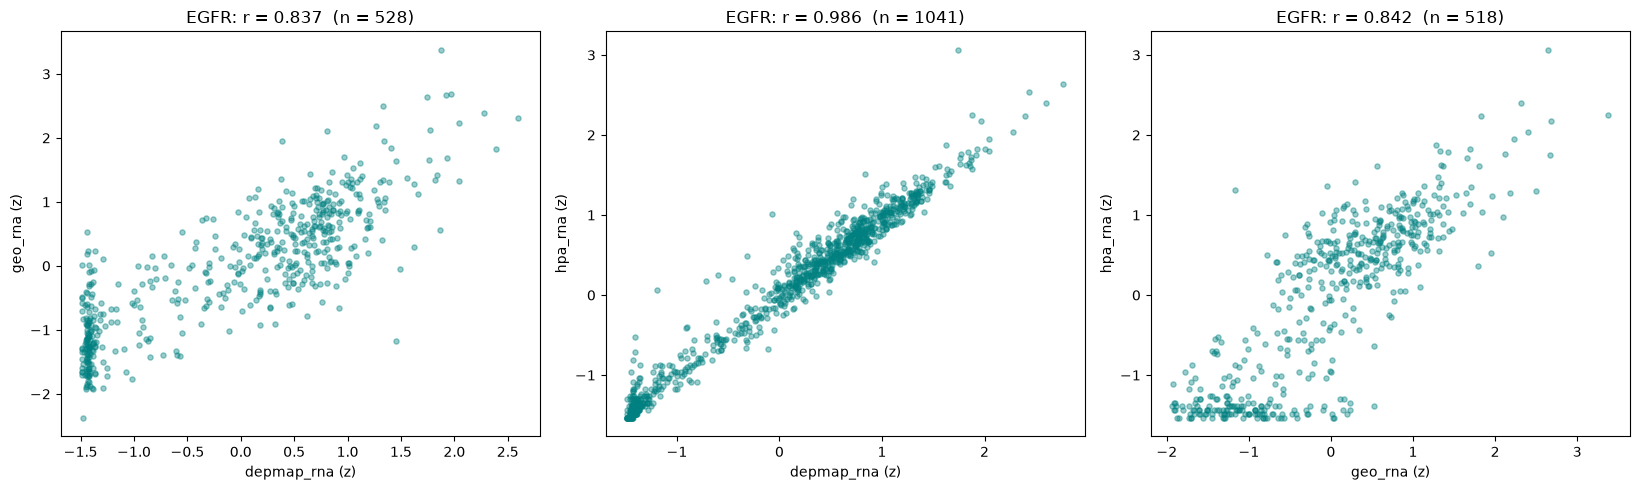

In [11]:
# 散点: DepMap RNA vs HPA RNA (标准化后)
pairs = [(a, b) for i, a in enumerate(std_cols) for b in std_cols[i+1:]]
if pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5.5*len(pairs), 5), squeeze=False)
    for ax, (a, b) in zip(axes[0], pairs):
        sub = egfr[[a, b]].dropna()
        ax.scatter(sub[a], sub[b], alpha=0.4, s=14, color='teal')
        r = sub[a].corr(sub[b]) if len(sub) > 2 else np.nan
        ax.set_xlabel(a.replace('__std', ' (z)'))
        ax.set_ylabel(b.replace('__std', ' (z)'))
        ax.set_title(f'EGFR: r = {r:.3f}  (n = {len(sub)})')
    plt.tight_layout()
    plt.savefig('../report/figures/rna_cross_source_concordance.png', dpi=150)
    plt.show()

## 6. 权重再分配 —— 缺失只降权, 不清零, 不删样本

In [12]:
base_weights = {'rna': 0.40, 'protein': 0.25, 'mutation': 0.15,
                'lineage': 0.10, 'completeness': 0.10}

row = egfr.query('~has_protein & has_rna').iloc[0]
mask = {'rna': bool(row['has_rna']), 'protein': bool(row['has_protein']),
        'mutation': False, 'lineage': True, 'completeness': True}
adj = redistribute_weights(mask, base_weights)

print(f'细胞系 {row["DepMap_ID"]}  has_rna={row["has_rna"]}  has_protein={row["has_protein"]}')
print(f'  原始权重: {base_weights}')
print(f'  调整后:   {{k: round(v, 3) for k, v in adj.items()}}')
print(f'\n  protein: {base_weights["protein"]}  ->  {adj["protein"]}   (缺失层置 0)')
print(f'  rna:     {base_weights["rna"]}  ->  {adj["rna"]:.3f}   '
      f'(权重上调, RNA 得分完整保留)')
print('\n→ 这就是硬性要求 3 的"缺蛋白仅降权、保留 RNA 得分、不删样本"')

细胞系 ACH-000002  has_rna=True  has_protein=False
  原始权重: {'rna': 0.4, 'protein': 0.25, 'mutation': 0.15, 'lineage': 0.1, 'completeness': 0.1}
  调整后:   {k: round(v, 3) for k, v in adj.items()}

  protein: 0.25  ->  0.0   (缺失层置 0)
  rna:     0.4  ->  0.667   (权重上调, RNA 得分完整保留)

→ 这就是硬性要求 3 的"缺蛋白仅降权、保留 RNA 得分、不删样本"


## 7. 覆盖度对比图 (答辩用)

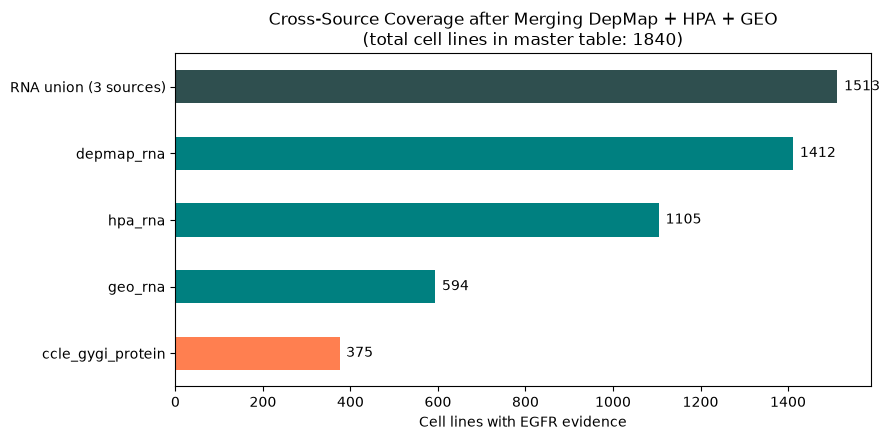

In [13]:
cov = pd.Series({c.replace('__raw', ''): egfr[c].notna().sum()
                 for c in egfr.columns if c.endswith('__raw')})
cov['RNA union (3 sources)'] = egfr['has_rna'].sum()
cov = cov.sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['coral' if 'protein' in i else
          ('darkslategray' if 'union' in i else 'teal') for i in cov.index]
cov.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Cell lines with EGFR evidence')
ax.set_title('Cross-Source Coverage after Merging DepMap + HPA + GEO\n'
             f'(total cell lines in master table: {len(egfr)})')
for i, v in enumerate(cov):
    ax.text(v + max(cov)*0.01, i, str(int(v)), va='center')
plt.tight_layout()
plt.savefig('../report/figures/merged_source_coverage.png', dpi=150)
plt.show()

## 8. 导出合并结果 (交给评分模型)

In [14]:
%%time
out_dir = Path('../data/merged')
out_dir.mkdir(exist_ok=True, parents=True)

GENES = ['EGFR', 'KRAS', 'ERBB2', 'MYC', 'TP53']

long = merger.build_long_table(genes=set(GENES))   # 基因过滤 -> 内存可控
long.to_parquet(out_dir / 'unified_long_table.parquet')
print(f'\n统一长表 {long.shape} 已导出')
print(long.groupby(['source', 'omics_layer', 'value_unit']).size().to_string())

→ depmap_rna (rna)
→ hpa_rna (rna)
  [hpa_rna] 490 行因 ID 未解析被跳过 (8.1%)
→ geo_rna (rna)
  [geo_rna] 基因列 'Gene' 装的是 ENSG, 将翻译为 symbol
  [geo_rna] File 3: 3,267 个 GSM 列, 其中 2,346 个可解析 -> 只读这些
→ ccle_gygi_protein (protein)

统一长表 (26620, 9) 已导出
source             omics_layer  value_unit       
ccle_gygi_protein  protein      log2_MS_intensity     1875
depmap_rna         rna          log2(TPM+1)           7475
geo_rna            rna          log2(intensity+1)    11730
hpa_rna            rna          log2(nTPM+1)          5540
CPU times: total: 15.3 s
Wall time: 15.3 s


In [15]:
for g in GENES:
    try:
        t = merger.build_gene_table(g)
        t.to_parquet(out_dir / f'gene_table_{g}.parquet')
        print(f'  ✓ {g:6}  {t.shape}  '
              f'RNA覆盖 {int(t["has_rna"].sum()):4}  '
              f'蛋白覆盖 {int(t["has_protein"].sum()):4}')
    except Exception as e:
        print(f'  ✗ {g}: {type(e).__name__}: {e}')

  ✓ EGFR    (1840, 17)  RNA覆盖 1513  蛋白覆盖  375
→ depmap_rna (rna)
→ hpa_rna (rna)
  [hpa_rna] 98 行因 ID 未解析被跳过 (8.1%)
→ geo_rna (rna)
  [geo_rna] 基因列 'Gene' 装的是 ENSG, 将翻译为 symbol
  [geo_rna] File 3: 3,267 个 GSM 列, 其中 2,346 个可解析 -> 只读这些
→ ccle_gygi_protein (protein)
  ✓ KRAS    (1840, 17)  RNA覆盖 1513  蛋白覆盖  312
→ depmap_rna (rna)
→ hpa_rna (rna)
  [hpa_rna] 98 行因 ID 未解析被跳过 (8.1%)
→ geo_rna (rna)
  [geo_rna] 基因列 'Gene' 装的是 ENSG, 将翻译为 symbol
  [geo_rna] File 3: 3,267 个 GSM 列, 其中 2,346 个可解析 -> 只读这些
→ ccle_gygi_protein (protein)
  ✓ ERBB2   (1840, 17)  RNA覆盖 1513  蛋白覆盖  375
→ depmap_rna (rna)
→ hpa_rna (rna)
  [hpa_rna] 98 行因 ID 未解析被跳过 (8.1%)
→ geo_rna (rna)
  [geo_rna] 基因列 'Gene' 装的是 ENSG, 将翻译为 symbol
  [geo_rna] File 3: 3,267 个 GSM 列, 其中 2,346 个可解析 -> 只读这些
→ ccle_gygi_protein (protein)
  ✓ MYC     (1840, 17)  RNA覆盖 1513  蛋白覆盖  276
→ depmap_rna (rna)
→ hpa_rna (rna)
  [hpa_rna] 98 行因 ID 未解析被跳过 (8.1%)
→ geo_rna (rna)
  [geo_rna] 基因列 'Gene' 装的是 ENSG, 将翻译为 symbol
  [geo_rna] File 3: 3,267 个 GSM

## 9. 硬性要求逐条自查 (答辩前跑一遍)

In [16]:
print('=' * 62)
print('硬性要求达成情况')
print('=' * 62)

n_src = len(merger._sources)
n_rna_src = sum(1 for s in merger._sources if s.layer == 'rna')
print(f'1. 多数据源统一 ID 对齐')
print(f'   已接入 {n_src} 个数据源 ({n_rna_src} 个 RNA 源: DepMap / HPA / GEO)')
print(f'   CVCL->ACH 字典: {cell_res.stats()["cvcl_to_ach"]:,} 条')
print(f'   全部落在统一主键 DepMap_ID 上: '
      f'{egfr["DepMap_ID"].str.startswith("ACH-").all()}')

print(f'\n2. 多组学统一结构化存储')
print(f'   统一长表 schema: {list(long.columns)}')
print(f'   单基因宽表: {egfr.shape[0]} 行 x {egfr.shape[1]} 列, 一行一细胞系')

print(f'\n3. 缺失值规范化处理')
print(f'   master 细胞系数 {n_expected}, 合并后 {egfr["DepMap_ID"].nunique()} —— 未删样本')
print(f'   缺蛋白细胞系 {int((~egfr["has_protein"]).sum())} 个, 全部保留')
print(f'   data_completeness 列已生成, 供置信度打分使用')

print(f'\n4. 数据可扩展性预留')
print(f'   OmicsSource 注册表模式; 新增源只需 .register(), 合并逻辑不变')
print(f'   当前已支持组学层: '
      f'{sorted(set(s.layer for s in merger._sources))}')
print('=' * 62)

硬性要求达成情况
1. 多数据源统一 ID 对齐
   已接入 4 个数据源 (3 个 RNA 源: DepMap / HPA / GEO)
   CVCL->ACH 字典: 1,895 条
   全部落在统一主键 DepMap_ID 上: True

2. 多组学统一结构化存储
   统一长表 schema: ['DepMap_ID', 'gene_symbol', 'ensembl_id', 'omics_layer', 'value_raw', 'value_unit', 'source', 'source_version', 'value_std']
   单基因宽表: 1840 行 x 17 列, 一行一细胞系

3. 缺失值规范化处理
   master 细胞系数 1840, 合并后 1840 —— 未删样本
   缺蛋白细胞系 1465 个, 全部保留
   data_completeness 列已生成, 供置信度打分使用

4. 数据可扩展性预留
   OmicsSource 注册表模式; 新增源只需 .register(), 合并逻辑不变
   当前已支持组学层: ['protein', 'rna']
